In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf
import time
from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from skimage import io
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import models, layers
import keras_tuner as kt

# Data Train

In [2]:
train = '224x224/train'
train

'224x224/train'

In [3]:
import pathlib
train_dir = pathlib.Path(train)
train_dir

WindowsPath('224x224/train')

In [4]:
image_count = (
    len(list(train_dir.glob('*/*.jpg'))) +
    len(list(train_dir.glob('*/*.png'))) +
    len(list(train_dir.glob('*/*.jpeg')))
)
print(image_count)

12012


In [5]:
train_image_dict = {
    'camera': list(train_dir.glob('camera/*')),
    'crt': list(train_dir.glob('crt/*')),
    'handphone': list(train_dir.glob('handphone/*')),
    'keyboard': list(train_dir.glob('keyboard/*')),
    'kulkas': list(train_dir.glob('kulkas/*')),
    'laptop': list(train_dir.glob('laptop/*')),
    'mesin cuci': list(train_dir.glob('mesin cuci/*')),
    'microwave': list(train_dir.glob('microwave/*')),
    'mouse': list(train_dir.glob('mouse/*')),
    'printer': list(train_dir.glob('printer/*')),
    'pv panel': list(train_dir.glob('pv panel/*')),
    'smartwatch': list(train_dir.glob('smartwatch/*')),
    'monitor flat': list(train_dir.glob('monitor flat/*')),
}

In [6]:
train_labels_dict = {
    'camera': 0,
    'crt': 1,
    'handphone': 2,
    'keyboard': 3,
    'kulkas': 4,
    'laptop': 5,
    'mesin cuci': 6,
    'microwave': 7,
    'mouse': 8,
    'printer': 9,
    'pv panel': 10,
    'smartwatch':11,
    'monitor flat':12
}

In [7]:
X, y, paths = [], [], []

for train_name, images in train_image_dict.items():
    for image in images:
        img = io.imread(image)
        X.append(img)
        y.append(train_labels_dict[train_name])
        paths.append(str(image))


# Data Validation

In [8]:
val = '224x224/val'
val

'224x224/val'

In [9]:
import pathlib
val_dir = pathlib.Path(val)
val_dir

WindowsPath('224x224/val')

In [10]:
image_count = (
    len(list(val_dir.glob('*/*.jpg'))) +
    len(list(val_dir.glob('*/*.png'))) +
    len(list(val_dir.glob('*/*.jpeg')))
)
print(image_count)

2574


In [11]:
val_image_dict = {
    'camera': list(val_dir.glob('camera/*')),
    'crt': list(val_dir.glob('crt/*')),
    'handphone': list(val_dir.glob('handphone/*')),
    'keyboard': list(val_dir.glob('keyboard/*')),
    'kulkas': list(val_dir.glob('kulkas/*')),
    'laptop': list(val_dir.glob('laptop/*')),
    'mesin cuci': list(val_dir.glob('mesin cuci/*')),
    'microwave': list(val_dir.glob('microwave/*')),
    'mouse': list(val_dir.glob('mouse/*')),
    'printer': list(val_dir.glob('printer/*')),
    'pv panel': list(val_dir.glob('pv panel/*')),
    'smartwatch': list(val_dir.glob('smartwatch/*')),
    'monitor flat': list(val_dir.glob('monitor flat/*')),
}

In [12]:
val_labels_dict = {
    'camera': 0,
    'crt': 1,
    'handphone': 2,
    'keyboard': 3,
    'kulkas': 4,
    'laptop': 5,
    'mesin cuci': 6,
    'microwave': 7,
    'mouse': 8,
    'printer': 9,
    'pv panel': 10,
    'smartwatch':11,
    'monitor flat':12
}

In [13]:
X_val, y_val, paths_val = [], [], []

for val_name, images in val_image_dict.items():
    for image in images:
        img = io.imread(image)
        X_val.append(img)
        y_val.append(val_labels_dict[val_name])
        paths_val.append(str(image))


In [14]:
X = np.array(X)
y = np.array(y)
X_val = np.array(X_val)
y_val = np.array(y_val)

# build model

In [15]:
def model_builder(hp):
    hp_learning_rate = hp.Choice('learning_rate', values=[0.001, 0.0001])
    hp_dropout = hp.Choice('dropout', values=[0.1, 0.3, 0.5])

    
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape = (224, 224, 3))

    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = True
        else:
            layer.trainable = False

    model = models.Sequential([layers.Input(shape=(224,224,3)),
                               layers.Rescaling(1./255),
                               base_model,
                               layers.GlobalAveragePooling2D(),
                               layers.Dropout(hp_dropout),
                               layers.Dense(13, activation='softmax')])
    

    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate= hp_learning_rate), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    return model

In [16]:
tuner = kt.GridSearch(
    model_builder,
    objective='val_loss',
    directory='tuner_dir',
    project_name='resnet_grid'
)

Reloading Tuner from tuner_dir\resnet_grid\tuner0.json


In [17]:
tuner.search(X, y, validation_data = (X_val, y_val), epochs = 8, shuffle=True)

Trial 6 Complete [00h 12m 47s]
val_loss: 0.21046894788742065

Best val_loss So Far: 0.12300322949886322
Total elapsed time: 01h 15m 46s


In [18]:
for trial_id, trial in tuner.oracle.trials.items():

    # metric
    val_loss = trial.metrics.get_last_value('val_loss')
    loss = trial.metrics.get_last_value('loss')

    val_acc = trial.metrics.get_last_value('val_accuracy')
    acc = trial.metrics.get_last_value('accuracy')

    # hyperparameter
    hp_values = trial.hyperparameters.values

    print("=" * 70)
    print(f"Trial ID : {trial_id}")

    print(
        f"loss={loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"acc={acc:.4f} | "
        f"val_acc={val_acc:.4f}"
    )

    print("\nHyperparameters:")

    for hp_name, hp_value in hp_values.items():
        print(f"{hp_name} : {hp_value}")

Trial ID : 0001
loss=0.0979 | val_loss=0.1230 | acc=0.9685 | val_acc=0.9592

Hyperparameters:
learning_rate : 0.001
dropout : 0.3
Trial ID : 0002
loss=0.0914 | val_loss=0.1286 | acc=0.9686 | val_acc=0.9615

Hyperparameters:
learning_rate : 0.001
dropout : 0.5
Trial ID : 0003
loss=0.2134 | val_loss=0.1920 | acc=0.9339 | val_acc=0.9468

Hyperparameters:
learning_rate : 0.0001
dropout : 0.1
Trial ID : 0000
loss=0.0691 | val_loss=0.1251 | acc=0.9778 | val_acc=0.9646

Hyperparameters:
learning_rate : 0.001
dropout : 0.1
Trial ID : 0004
loss=0.2601 | val_loss=0.1901 | acc=0.9167 | val_acc=0.9448

Hyperparameters:
learning_rate : 0.0001
dropout : 0.3
Trial ID : 0005
loss=0.3338 | val_loss=0.2105 | acc=0.8889 | val_acc=0.9351

Hyperparameters:
learning_rate : 0.0001
dropout : 0.5


In [19]:
# Menapilkan Hyperparameter Terbaik

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(best_hps.values)

{'learning_rate': 0.001, 'dropout': 0.3}


# Train Model 

In [20]:
model = tuner.hypermodel.build(best_hps)

In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 13)                26637     
                                                                 
Total params: 23,614,349
Trainable params: 79,757
Non-trainable params: 23,534,592
_______________________________________

In [22]:
start = time.time()
history = model.fit(X, y, validation_data=(X_val, y_val), epochs=15, shuffle=True)
end = time.time()

Epoch 1/15
376/376 [==============================] - 116s 242ms/step - loss: 0.5908 - accuracy: 0.8113 - val_loss: 2.8088 - val_accuracy: 0.1706
Epoch 2/15
376/376 [==============================] - 92s 245ms/step - loss: 0.2320 - accuracy: 0.9238 - val_loss: 0.4599 - val_accuracy: 0.8528
Epoch 3/15
376/376 [==============================] - 92s 245ms/step - loss: 0.1626 - accuracy: 0.9455 - val_loss: 0.1533 - val_accuracy: 0.9542
Epoch 4/15
376/376 [==============================] - 88s 233ms/step - loss: 0.1288 - accuracy: 0.9584 - val_loss: 0.1346 - val_accuracy: 0.9604
Epoch 5/15
376/376 [==============================] - 88s 233ms/step - loss: 0.0900 - accuracy: 0.9699 - val_loss: 0.1336 - val_accuracy: 0.9549
Epoch 6/15
376/376 [==============================] - 88s 233ms/step - loss: 0.0862 - accuracy: 0.9714 - val_loss: 0.1412 - val_accuracy: 0.9596
Epoch 7/15
376/376 [==============================] - 88s 233ms/step - loss: 0.0698 - accuracy: 0.9757 - val_loss: 0.1446 - val_a

In [23]:
waktu_training = end-start
minutes = int(waktu_training // 60)  # Bagian menit
seconds = waktu_training % 60
print(f"{waktu_training} detik = {minutes} menit {seconds:.2f} detik")

1360.1204867362976 detik = 22 menit 40.12 detik


# Grafik

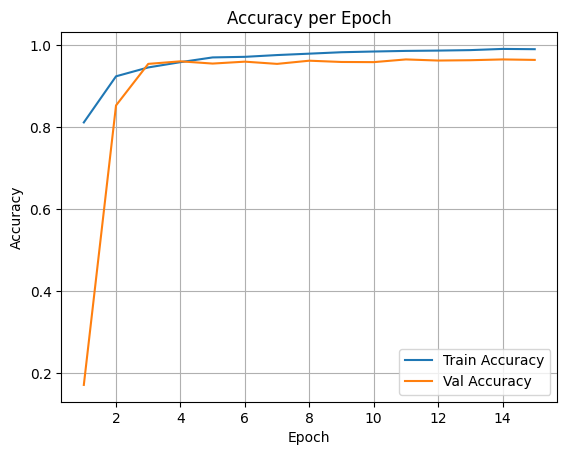

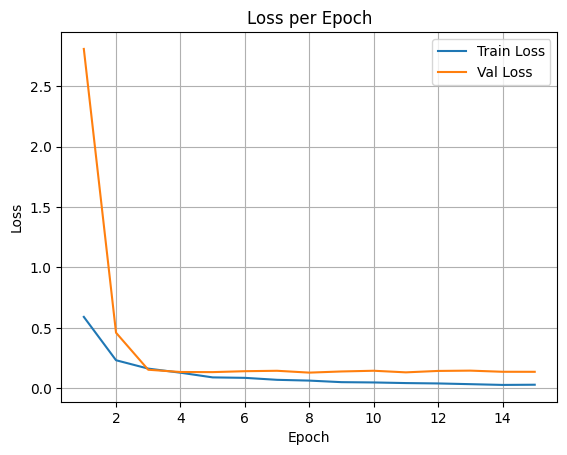

In [24]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['accuracy']) + 1)

# Akurasi
plt.plot(epochs, history.history['accuracy'], label='Train Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Data Test

In [25]:
test = '224x224/test'
test

'224x224/test'

In [26]:
import pathlib
test_dir = pathlib.Path(test)
test_dir

WindowsPath('224x224/test')

In [27]:
image_count = (
    len(list(test_dir.glob('*/*.jpg'))) +
    len(list(test_dir.glob('*/*.png'))) +
    len(list(test_dir.glob('*/*.jpeg')))
)
print(image_count)

2574


In [28]:
test_image_dict = {
    'camera': list(test_dir.glob('camera/*')),
    'crt': list(test_dir.glob('crt/*')),
    'handphone': list(test_dir.glob('handphone/*')),
    'keyboard': list(test_dir.glob('keyboard/*')),
    'kulkas': list(test_dir.glob('kulkas/*')),
    'laptop': list(test_dir.glob('laptop/*')),
    'mesin cuci': list(test_dir.glob('mesin cuci/*')),
    'microwave': list(test_dir.glob('microwave/*')),
    'mouse': list(test_dir.glob('mouse/*')),
    'printer': list(test_dir.glob('printer/*')),
    'pv panel': list(test_dir.glob('pv panel/*')),
    'smartwatch': list(test_dir.glob('smartwatch/*')),
    'monitor flat': list(test_dir.glob('monitor flat/*')),
}

In [29]:
test_labels_dict = {
    'camera': 0,
    'crt': 1,
    'handphone': 2,
    'keyboard': 3,
    'kulkas': 4,
    'laptop': 5,
    'mesin cuci': 6,
    'microwave': 7,
    'mouse': 8,
    'printer': 9,
    'pv panel': 10,
    'smartwatch':11,
    'monitor flat':12
}

In [30]:
X_test, y_test, paths_test = [], [], []

for test_name, images in test_image_dict.items():
    for image in images:
        img = io.imread(image)
        X_test.append(img)
        y_test.append(test_labels_dict[test_name])
        paths_test.append(str(image))


In [31]:
X_test = np.array(X_test)
y_test = np.array(y_test)

In [32]:
model.evaluate(X_test, y_test)

81/81 [==============================] - 7s 76ms/step - loss: 0.1865 - accuracy: 0.9561


[0.18645377457141876, 0.9560994505882263]

# Confusion Matrix

In [33]:
import numpy as np
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

81/81 [==============================] - 9s 68ms/step


In [34]:
from sklearn.metrics import confusion_matrix

In [35]:
cm = confusion_matrix(y_test, y_pred)

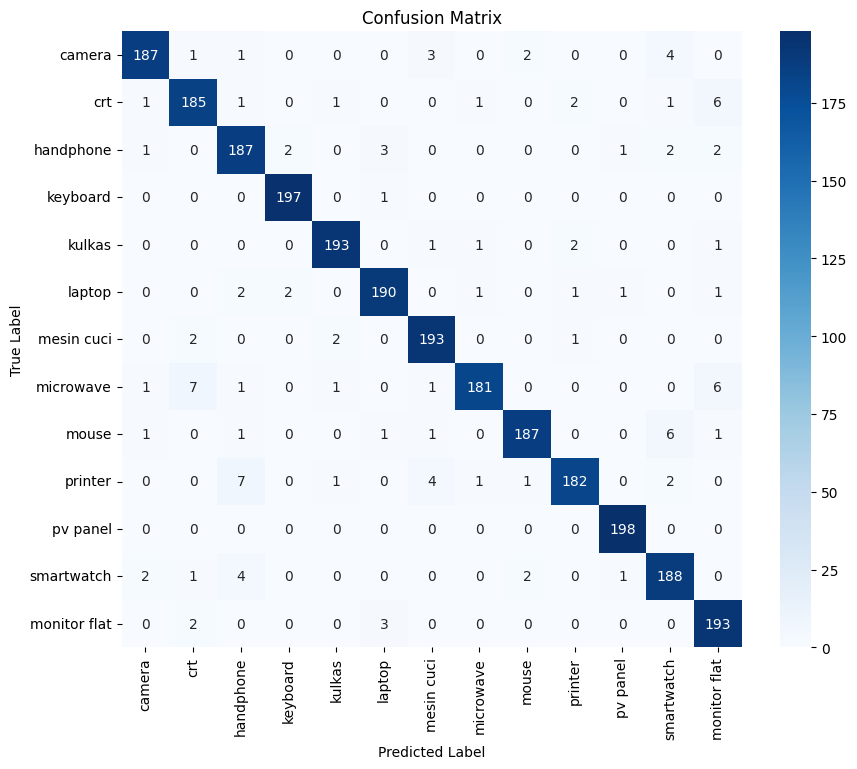

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = list(test_labels_dict.keys())

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Save Model

In [37]:
# model.save('model.h5')